# Assignment 4 – Scenario 1  
## Comparing Cale Makar and Quinn Hughes as Trade Targets

### Introduction

In this notebook, I will compare Cale Makar and Quinn Hughes using offensive data from the NHL player dataset.

The goal is simple: if a general manager had to trade for one elite defenseman, which player would be the better offensive choice?

I will follow the same EDA process from class:

1. Ask questions  
2. Load and prepare the data  
3. Explore the data with charts and summary tables  
4. Draw insights and make a recommendation  

This notebook focuses on offensive performance, so I will mainly look at:

- goals  
- primary assists  
- points  
- shots on goal  
- expected goals (xG)  

At the end, I will give a clear recommendation based on the data.

---
## Step 1 – Ask Questions

1. Which player produced more offense from season to season?  
2. Who had the stronger overall totals across the shared sample?  
3. Who was more efficient on a per-game basis?  
4. Did either player score above or below expected goals?  
5. Which player looks like the better offensive trade target based on the data?

These questions will help keep the notebook focused.

---
## Step 2 – Load and Prepare the Data

First, I will load the player dataset and keep only the rows I need for this scenario.

### Why this matters

The full dataset includes many players, many situations, and many columns.  
To make the comparison fair and easy to read, I need to:

- keep only Cale Makar and Quinn Hughes
- use all situations
- focus on the offensive columns that match the assignment
- remove Quinn Hughes's short 2018 sample from the main comparison

I am removing the 2018 Quinn Hughes row because it was only a very small sample and would not be a fair season-to-season comparison with Makar.

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option("display.max_columns", 200)
pd.set_option("display.float_format", lambda x: f"{x:.2f}")

plt.style.use("ggplot")

data_path = Path("combined_player_data.csv")
dictionary_path = Path("DataDictionaryForPlayers.csv")

players_df = pd.read_csv(data_path)
data_dictionary = pd.read_csv(dictionary_path)

players_df.head()

,playerId,season,name,team,position,situation,games_played,icetime,shifts,gameScore,onIce_xGoalsPercentage,offIce_xGoalsPercentage,onIce_corsiPercentage,offIce_corsiPercentage,onIce_fenwickPercentage,offIce_fenwickPercentage,iceTimeRank,I_F_xOnGoal,I_F_xGoals,I_F_xRebounds,I_F_xFreeze,I_F_xPlayStopped,I_F_xPlayContinuedInZone,I_F_xPlayContinuedOutsideZone,I_F_flurryAdjustedxGoals,I_F_scoreVenueAdjustedxGoals,I_F_flurryScoreVenueAdjustedxGoals,I_F_primaryAssists,I_F_secondaryAssists,I_F_shotsOnGoal,I_F_missedShots,I_F_blockedShotAttempts,I_F_shotAttempts,I_F_points,I_F_goals,I_F_rebounds,I_F_reboundGoals,I_F_freeze,I_F_playStopped,I_F_playContinuedInZone,I_F_playContinuedOutsideZone,I_F_savedShotsOnGoal,I_F_savedUnblockedShotAttempts,penalties,I_F_penalityMinutes,I_F_faceOffsWon,I_F_hits,I_F_takeaways,I_F_giveaways,I_F_lowDangerShots,I_F_mediumDangerShots,I_F_highDangerShots,I_F_lowDangerxGoals,I_F_mediumDangerxGoals,I_F_highDangerxGoals,I_F_lowDangerGoals,I_F_mediumDangerGoals,I_F_highDangerGoals,I_F_scoreAdjustedShotsAttempts,I_F_unblockedShotAttempts,I_F_scoreAdjustedUnblockedShotAttempts,I_F_dZoneGiveaways,I_F_xGoalsFromxReboundsOfShots,I_F_xGoalsFromActualReboundsOfShots,I_F_reboundxGoals,I_F_xGoals_with_earned_rebounds,I_F_xGoals_with_earned_rebounds_scoreAdjusted,I_F_xGoals_with_earned_rebounds_scoreFlurryAdjusted,I_F_shifts,I_F_oZoneShiftStarts,I_F_dZoneShiftStarts,I_F_neutralZoneShiftStarts,I_F_flyShiftStarts,I_F_oZoneShiftEnds,I_F_dZoneShiftEnds,I_F_neutralZoneShiftEnds,I_F_flyShiftEnds,faceoffsWon,faceoffsLost,timeOnBench,penalityMinutes,penalityMinutesDrawn,penaltiesDrawn,shotsBlockedByPlayer,OnIce_F_xOnGoal,OnIce_F_xGoals,OnIce_F_flurryAdjustedxGoals,OnIce_F_scoreVenueAdjustedxGoals,OnIce_F_flurryScoreVenueAdjustedxGoals,OnIce_F_shotsOnGoal,OnIce_F_missedShots,OnIce_F_blockedShotAttempts,OnIce_F_shotAttempts,OnIce_F_goals,OnIce_F_rebounds,OnIce_F_reboundGoals,OnIce_F_lowDangerShots,OnIce_F_mediumDangerShots,OnIce_F_highDangerShots,OnIce_F_lowDangerxGoals,OnIce_F_mediumDangerxGoals,OnIce_F_highDangerxGoals,OnIce_F_lowDangerGoals,OnIce_F_mediumDangerGoals,OnIce_F_highDangerGoals,OnIce_F_scoreAdjustedShotsAttempts,OnIce_F_unblockedShotAttempts,OnIce_F_scoreAdjustedUnblockedShotAttempts,OnIce_F_xGoalsFromxReboundsOfShots,OnIce_F_xGoalsFromActualReboundsOfShots,OnIce_F_reboundxGoals,OnIce_F_xGoals_with_earned_rebounds,OnIce_F_xGoals_with_earned_rebounds_scoreAdjusted,OnIce_F_xGoals_with_earned_rebounds_scoreFlurryAdjusted,OnIce_A_xOnGoal,OnIce_A_xGoals,OnIce_A_flurryAdjustedxGoals,OnIce_A_scoreVenueAdjustedxGoals,OnIce_A_flurryScoreVenueAdjustedxGoals,OnIce_A_shotsOnGoal,OnIce_A_missedShots,OnIce_A_blockedShotAttempts,OnIce_A_shotAttempts,OnIce_A_goals,OnIce_A_rebounds,OnIce_A_reboundGoals,OnIce_A_lowDangerShots,OnIce_A_mediumDangerShots,OnIce_A_highDangerShots,OnIce_A_lowDangerxGoals,OnIce_A_mediumDangerxGoals,OnIce_A_highDangerxGoals,OnIce_A_lowDangerGoals,OnIce_A_mediumDangerGoals,OnIce_A_highDangerGoals,OnIce_A_scoreAdjustedShotsAttempts,OnIce_A_unblockedShotAttempts,OnIce_A_scoreAdjustedUnblockedShotAttempts,OnIce_A_xGoalsFromxReboundsOfShots,OnIce_A_xGoalsFromActualReboundsOfShots,OnIce_A_reboundxGoals,OnIce_A_xGoals_with_earned_rebounds,OnIce_A_xGoals_with_earned_rebounds_scoreAdjusted,OnIce_A_xGoals_with_earned_rebounds_scoreFlurryAdjusted,OffIce_F_xGoals,OffIce_A_xGoals,OffIce_F_shotAttempts,OffIce_A_shotAttempts,xGoalsForAfterShifts,xGoalsAgainstAfterShifts,corsiForAfterShifts,corsiAgainstAfterShifts,fenwickForAfterShifts,fenwickAgainstAfterShifts
0,8469459,2015,Mikko Koivu,MIN,C,other,82,7197.00,116.00,50.37,0.55,0.45,0.59,0.34,0.59,0.36,206.00,11.07,4.21,0.65,1.39,0.33,4.95,3.48,4.12,4.21,4.12,0.00,3.00,11.00,4.00,4.00,19.00,7.00,4.00,1.00,0.00,2.00,0.00,3.00,5.00,7.00,11.00,4.00,8.00,63.00,2.00,1.00,3.00,5.00,4.00,6.00,0.21,0.47,3.53,0.00,0.00,4.00,19.00,15.00,15.00,2.00,0.21,0.18,0.73,3.68,3.68,3.66,116.00,32.00,20.00,22.00,42.00,14.00,8.00,27.00,67.00,63.00,62.00,8007.00,8.00,0.00,0.00,7.00,82.18,16.58,15

In [16]:
# Keep only the two players and the "all" situation
scenario_df = players_df[
    (players_df["name"].isin(["Cale Makar", "Quinn Hughes"])) &
    (players_df["situation"] == "all")
].copy()

# Keep only the columns I need for this analysis
scenario_df = scenario_df[
    [
        "season",
        "name",
        "team",
        "position",
        "games_played",
        "I_F_goals",
        "I_F_primaryAssists",
        "I_F_points",
        "I_F_shotsOnGoal",
        "I_F_xGoals"
    ]
].sort_values(["season", "name"])

scenario_df

,season,name,team,position,games_played,I_F_goals,I_F_primaryAssists,I_F_points,I_F_shotsOnGoal,I_F_xGoals
15571,2018,Quinn Hughes,VAN,D,5,0.00,3.00,3.00,6.00,0.23
19676,2019,Cale Makar,COL,D,57,12.00,22.00,50.00,121.00,8.92
21076,2019,Quinn Hughes,VAN,D,68,8.00,23.00,53.00,125.00,5.84
24066,2020,Cale Makar,COL,D,44,8.00,22.00,44.00,104.00,5.26
26596,2020,Quinn Hughes,VAN,D,56,3.00,20.00,41.00,98.00,4.89
29541,2021,Cale Makar,COL,D,77,28.00,29.00,86.00,240.00,15.02
27431,2021,Quinn Hughes,VAN,D,76,8.00,31.00,68.00,150.00,6.36
35806,2022,Cale Makar,COL,D,60,17.00,29.00,66.00,176.00,12.26
33116,2022,Quinn Hughes,VAN,D,78,7.00,35.00,76.00,154.00,6.25
37871,2023,Cale Makar,COL,D,77,21.00,28.00,90.00,231.00,16.43


In [17]:
# Remove the small 2018 Quinn Hughes sample for the main comparison
comparison_df = scenario_df[scenario_df["season"] >= 2019].copy()

# Create per-game stats to make the comparison fair
comparison_df["goals_per_game"] = comparison_df["I_F_goals"] / comparison_df["games_played"]
comparison_df["primary_assists_per_game"] = comparison_df["I_F_primaryAssists"] / comparison_df["games_played"]
comparison_df["points_per_game"] = comparison_df["I_F_points"] / comparison_df["games_played"]
comparison_df["shots_per_game"] = comparison_df["I_F_shotsOnGoal"] / comparison_df["games_played"]
comparison_df["xGoals_per_game"] = comparison_df["I_F_xGoals"] / comparison_df["games_played"]
comparison_df["goal_minus_xG"] = comparison_df["I_F_goals"] - comparison_df["I_F_xGoals"]

comparison_df

,season,name,team,position,games_played,I_F_goals,I_F_primaryAssists,I_F_points,I_F_shotsOnGoal,I_F_xGoals,goals_per_game,primary_assists_per_game,points_per_game,shots_per_game,xGoals_per_game,goal_minus_xG
19676,2019,Cale Makar,COL,D,57,12.00,22.00,50.00,121.00,8.92,0.21,0.39,0.88,2.12,0.16,3.08
21076,2019,Quinn Hughes,VAN,D,68,8.00,23.00,53.00,125.00,5.84,0.12,0.34,0.78,1.84,0.09,2.16
24066,2020,Cale Makar,COL,D,44,8.00,22.00,44.00,104.00,5.26,0.18,0.50,1.00,2.36,0.12,2.74
26596,2020,Quinn Hughes,VAN,D,56,3.00,20.00,41.00,98.00,4.89,0.05,0.36,0.73,1.75,0.09,-1.89
29541,2021,Cale Makar,COL,D,77,28.00,29.00,86.00,240.00,15.02,0.36,0.38,1.12,3.12,0.20,12.98
27431,2021,Quinn Hughes,VAN,D,76,8.00,31.00,68.00,150.00,6.36,0.11,0.41,0.89,1.97,0.08,1.64
35806,2022,Cale Makar,COL,D,60,17.00,29.00,66.00,176.00,12.26,0.28,0.48,1.10,2.93,0.20,4.74
33116,2022,Quinn Hughes,VAN,D,78,7.00,35.00,76.00,154.00,6.25,0.09,0.45,0.97,1.97,0.08,0.75
37871,2023,Cale Makar,COL,D,77,21.00,28.00,90.00,231.00,16.43,0.27,0.36,1.17,3.00,0.21,4.57
40276,2023,Quinn Hughes,VAN,D,82,17.00,35.00,92.00,199.00,11.18,0.21,0.43,1.12,2.43,0.14,5.82


### Quick check of the prepared data

Now I have a clean six-season comparison from **2019 to 2024**.  
This gives both players the same time window, which makes the analysis much fairer.

In [18]:
comparison_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 12 entries, 19676 to 45816
Data columns (total 16 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   season                    12 non-null     int64  
 1   name                      12 non-null     object 
 2   team                      12 non-null     object 
 3   position                  12 non-null     object 
 4   games_played              12 non-null     int64  
 5   I_F_goals                 12 non-null     float64
 6   I_F_primaryAssists        12 non-null     float64
 7   I_F_points                12 non-null     float64
 8   I_F_shotsOnGoal           12 non-null     float64
 9   I_F_xGoals                12 non-null     float64
 10  goals_per_game            12 non-null     float64
 11  primary_assists_per_game  12 non-null     float64
 12  points_per_game           12 non-null     float64
 13  shots_per_game            12 non-null     float64
 14  xGoals_per

---
## Step 3 – Explore the Data

Now I can start answering the questions one by one.

### Question 1: Who produced more offense over time?

I will start with points because points give a quick view of overall offensive production.

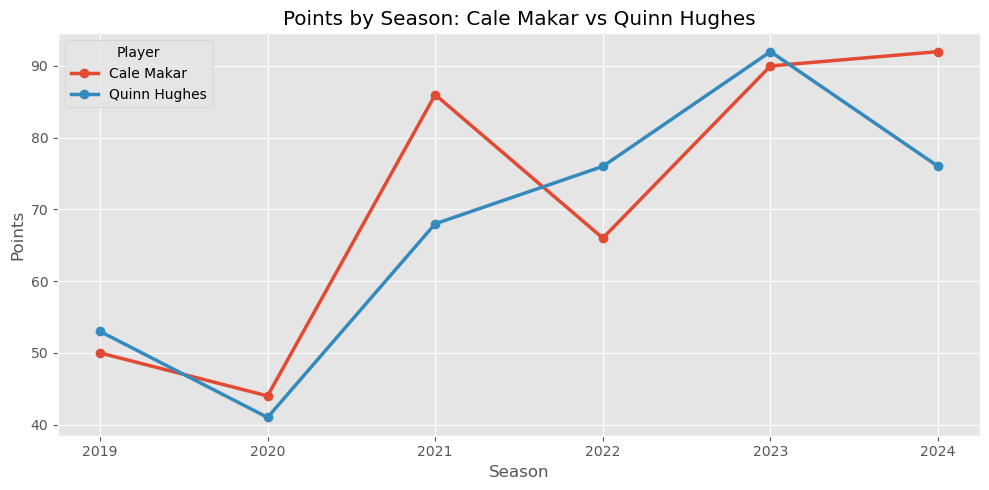

In [19]:
plt.figure(figsize=(10, 5))
for player_name, player_data in comparison_df.groupby("name"):
    plt.plot(player_data["season"], player_data["I_F_points"], marker="o", linewidth=2.5, label=player_name)
plt.title("Points by Season: Cale Makar vs Quinn Hughes")
plt.xlabel("Season")
plt.ylabel("Points")
plt.legend(title="Player")
plt.tight_layout()
plt.show()


### Interpretation

Both players were strong offensive defensemen across the full period.

A few things stand out here:

- **Cale Makar** had the higher point total in most of the shared seasons.
- **Quinn Hughes** had a very strong peak in 2023 and matched or beat Makar in a couple of seasons.
- Makar's line is a little stronger overall, especially when looking at the full six-year sample.

So from a points trend view, Makar looks slightly better overall, but Hughes clearly belongs in the same top tier.

---
### Question 2: Is one player more goal-driven and one more playmaking-driven?

Points are helpful, but they do not show *how* those points were created.

To dig deeper, I will compare:

- goals
- primary assists

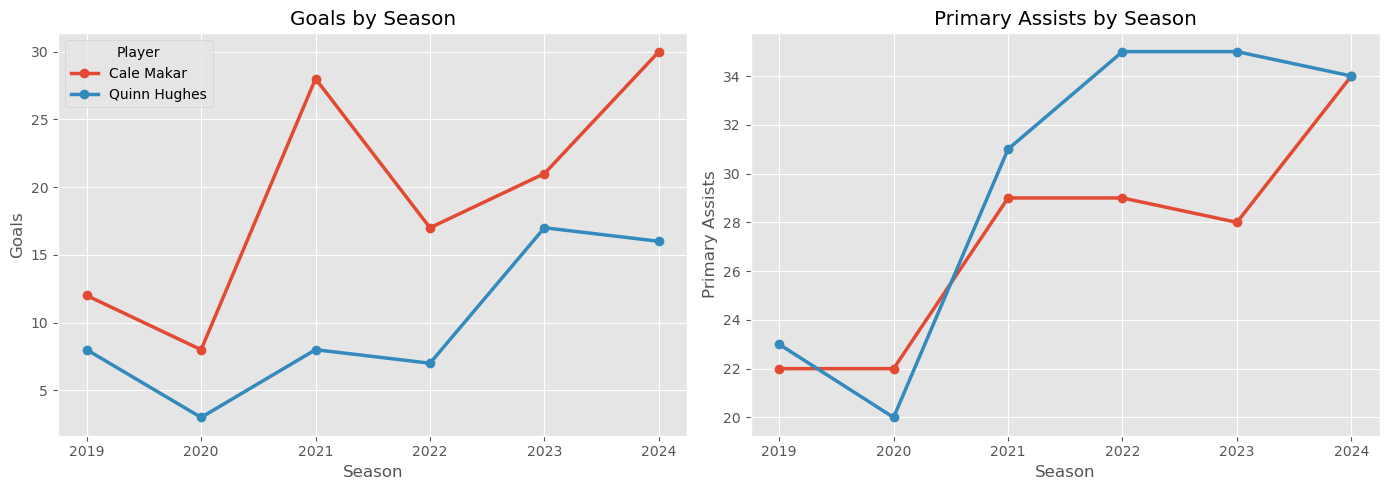

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for player_name, player_data in comparison_df.groupby("name"):
    axes[0].plot(player_data["season"], player_data["I_F_goals"], marker="o", linewidth=2.5, label=player_name)
axes[0].set_title("Goals by Season")
axes[0].set_xlabel("Season")
axes[0].set_ylabel("Goals")

for player_name, player_data in comparison_df.groupby("name"):
    axes[1].plot(player_data["season"], player_data["I_F_primaryAssists"], marker="o", linewidth=2.5, label=player_name)
axes[1].set_title("Primary Assists by Season")
axes[1].set_xlabel("Season")
axes[1].set_ylabel("Primary Assists")

axes[0].legend(title="Player")
plt.tight_layout()
plt.show()


### Interpretation

This chart shows a pretty clear difference in style.

- **Cale Makar** was much stronger as a goal scorer.
- **Quinn Hughes** was excellent as a playmaker and actually finished with slightly more total primary assists across the full shared sample.
- This makes the comparison more interesting, because the two players are not producing offense in exactly the same way.

So far, the data suggests:

- Makar brings more shooting and finishing value
- Hughes brings strong setup and passing value

---
### Question 3: Who had the stronger overall offensive totals?

Next, I want to compare the six-season totals directly.

In [21]:
summary_totals = comparison_df.groupby("name").agg(
    total_games=("games_played", "sum"),
    total_goals=("I_F_goals", "sum"),
    total_primary_assists=("I_F_primaryAssists", "sum"),
    total_points=("I_F_points", "sum"),
    total_shots=("I_F_shotsOnGoal", "sum"),
    total_xGoals=("I_F_xGoals", "sum")
).round(2)

summary_totals

,total_games,total_goals,total_primary_assists,total_points,total_shots,total_xGoals
name,,,,,,
Cale Makar,395,116.00,164.00,428.00,1118.00,78.22
Quinn Hughes,428,59.00,178.00,406.00,919.00,43.42


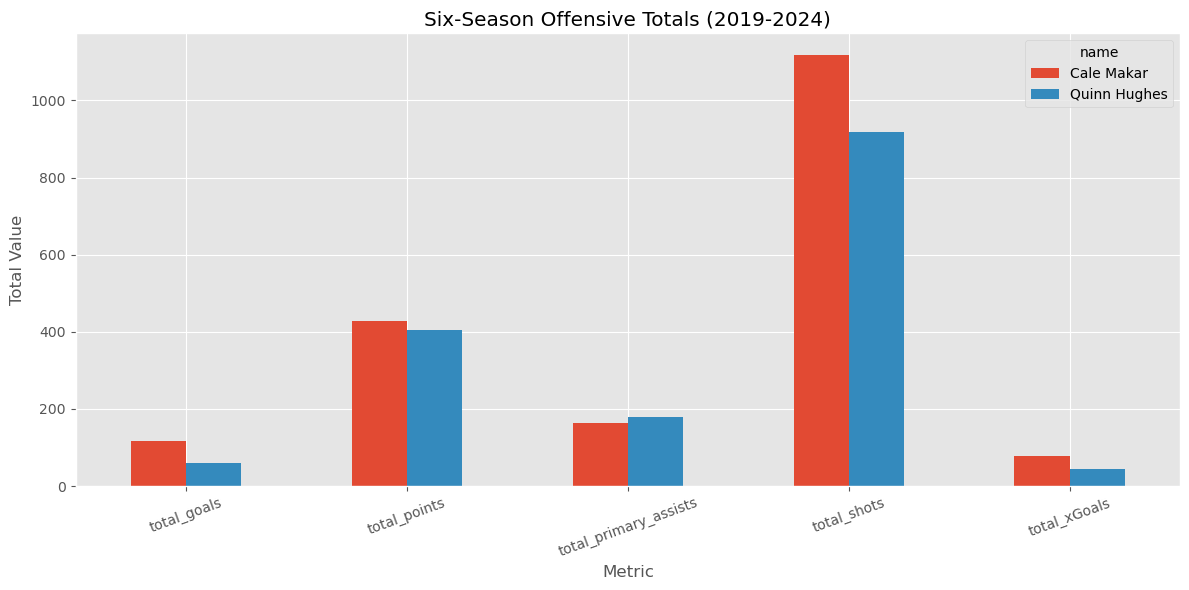

In [22]:
summary_totals_plot = summary_totals.reset_index().melt(
    id_vars="name",
    value_vars=["total_goals", "total_primary_assists", "total_points", "total_shots", "total_xGoals"],
    var_name="metric",
    value_name="value"
)

pivot_totals_plot = summary_totals_plot.pivot(index="metric", columns="name", values="value")
pivot_totals_plot.plot(kind="bar", figsize=(12, 6))
plt.title("Six-Season Offensive Totals (2019-2024)")
plt.xlabel("Metric")
plt.ylabel("Total Value")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


### Interpretation

The total table makes the overall picture clearer.

Across the shared six-season sample:

- Cale Makar had **428 points**, compared with **406** for Quinn Hughes.
- Makar also had a huge edge in goals (**116 vs 59**).
- Makar generated more shots on goal (**1118 vs 919**).
- Makar also had much higher expected goals (**78.22 vs 43.42**).
- Quinn Hughes finished with slightly more primary assists (**178 vs 164**).

This tells me that Hughes is a very strong creator, but Makar gives more complete offensive pressure overall, especially in shooting and scoring.

---
### Question 4: Who was better on a per-game basis?

Raw totals are useful, but games played are not exactly the same.  
Because of that, I also want to compare efficiency.

Per-game numbers help show who created more offense each time they played.

In [23]:
summary_rates = comparison_df.groupby("name").agg(
    avg_goals_per_game=("goals_per_game", "mean"),
    avg_primary_assists_per_game=("primary_assists_per_game", "mean"),
    avg_points_per_game=("points_per_game", "mean"),
    avg_shots_per_game=("shots_per_game", "mean"),
    avg_xGoals_per_game=("xGoals_per_game", "mean")
).round(3)

summary_rates

,avg_goals_per_game,avg_primary_assists_per_game,avg_points_per_game,avg_shots_per_game,avg_xGoals_per_game
name,,,,,
Cale Makar,0.28,0.42,1.07,2.77,0.19
Quinn Hughes,0.14,0.41,0.94,2.13,0.10


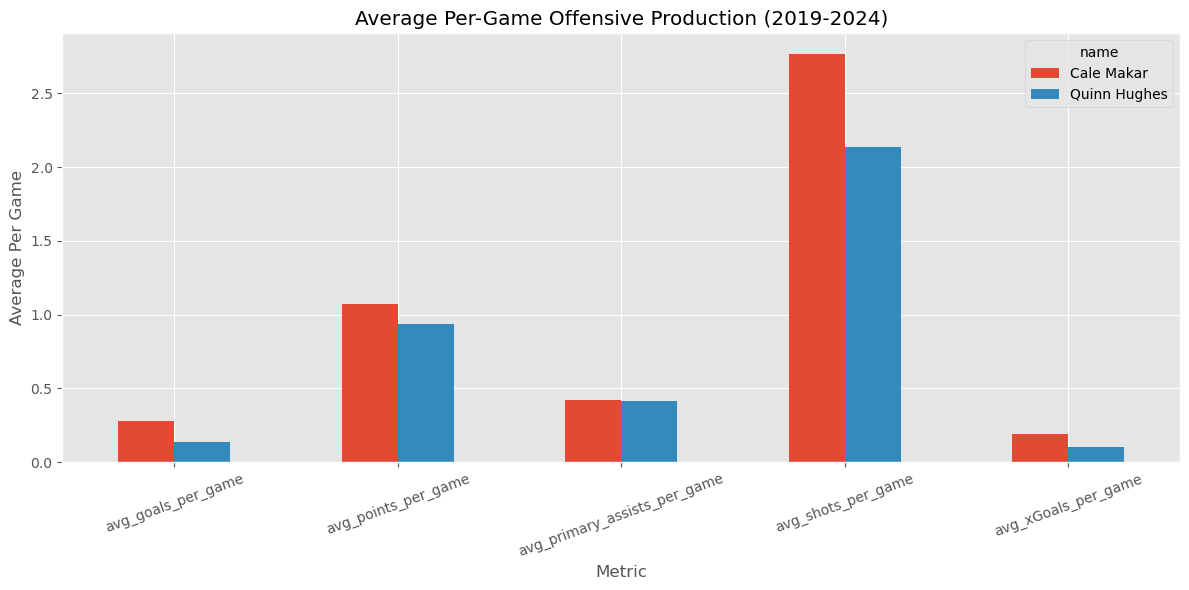

In [24]:
summary_rates_plot = summary_rates.reset_index().melt(
    id_vars="name",
    var_name="metric",
    value_name="value"
)

pivot_rates_plot = summary_rates_plot.pivot(index="metric", columns="name", values="value")
pivot_rates_plot.plot(kind="bar", figsize=(12, 6))
plt.title("Average Per-Game Offensive Production (2019-2024)")
plt.xlabel("Metric")
plt.ylabel("Average Per Game")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


### Interpretation

The per-game view supports the same general conclusion.

On average, Makar was better in:

- goals per game
- points per game
- shots per game
- xGoals per game

The point that stands out most to me is points per game:

- **Cale Makar: 1.07**
- **Quinn Hughes: 0.94**

That difference is meaningful because it shows Makar produced more offense even after adjusting for games played.

Hughes still looks strong as a passer, but Makar was the more dangerous all-around offensive player on a game-by-game basis.

---
### Question 5: Did either player score above or below expected goals?

Expected goals (xG) can help show how much offense a player should have created based on shot quality.

Comparing actual goals to xG helps answer questions like:

- Is this player finishing really well?
- Is this player getting unlucky?
- Is the scoring level supported by chance creation?

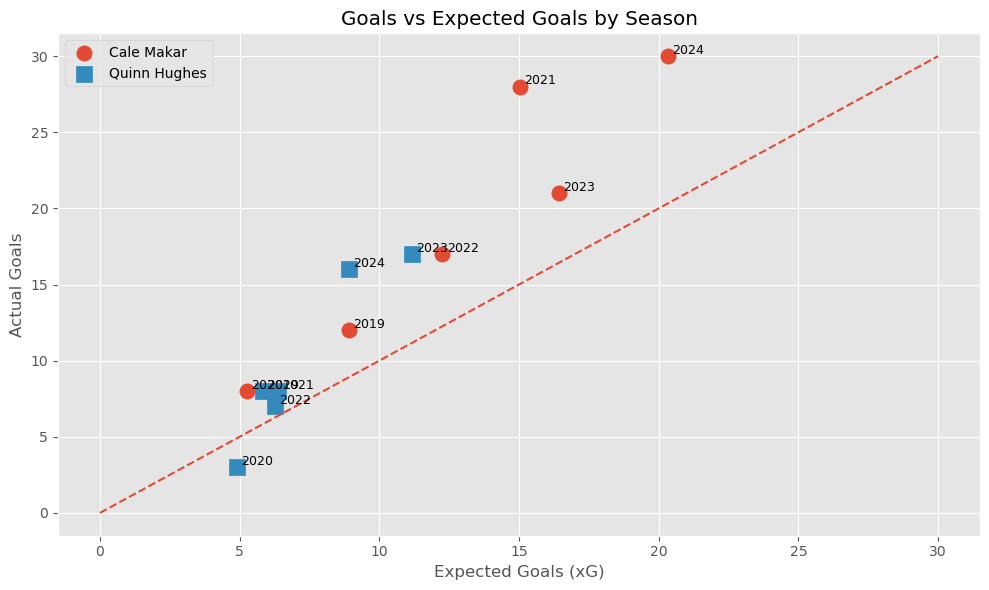

In [25]:
plt.figure(figsize=(10, 6))
markers = {"Cale Makar": "o", "Quinn Hughes": "s"}
for player_name, player_data in comparison_df.groupby("name"):
    plt.scatter(
        player_data["I_F_xGoals"],
        player_data["I_F_goals"],
        s=120,
        marker=markers.get(player_name, "o"),
        label=player_name
    )

max_value = max(comparison_df["I_F_xGoals"].max(), comparison_df["I_F_goals"].max())
plt.plot([0, max_value], [0, max_value], linestyle="--")

for _, row in comparison_df.iterrows():
    plt.text(row["I_F_xGoals"] + 0.15, row["I_F_goals"] + 0.15, str(int(row["season"])), fontsize=9)

plt.title("Goals vs Expected Goals by Season")
plt.xlabel("Expected Goals (xG)")
plt.ylabel("Actual Goals")
plt.legend()
plt.tight_layout()
plt.show()


In [26]:
xg_summary = comparison_df.groupby("name").agg(
    total_goals=("I_F_goals", "sum"),
    total_xGoals=("I_F_xGoals", "sum")
)

xg_summary["goal_minus_xG"] = xg_summary["total_goals"] - xg_summary["total_xGoals"]
xg_summary.round(2)

,total_goals,total_xGoals,goal_minus_xG
name,,,
Cale Makar,116.00,78.22,37.78
Quinn Hughes,59.00,43.42,15.58


### Interpretation

Both players scored more goals than their expected goals total, which means both of them outperformed xG overall.

But the size of the gap is very different:

- **Cale Makar:** +37.78 goals above xG
- **Quinn Hughes:** +15.58 goals above xG

This does not automatically mean Makar is "luckier."  
A better way to read it is that Makar combined:

- stronger shot volume
- stronger chance quality
- much stronger finishing results

This is another reason why his offensive profile looks more dangerous.

---

### Question 6: Who looked more consistent?

For a trade decision, consistency matters too.  

To check consistency, I will compare average points per game and the variation around that number.

In [27]:
consistency_summary = comparison_df.groupby("name").agg(
    average_points_per_game=("points_per_game", "mean"),
    std_points_per_game=("points_per_game", "std"),
    min_points=("I_F_points", "min"),
    max_points=("I_F_points", "max")
).round(3)

consistency_summary

,average_points_per_game,std_points_per_game,min_points,max_points
name,,,,
Cale Makar,1.07,0.11,44.00,92.00
Quinn Hughes,0.94,0.17,41.00,92.00


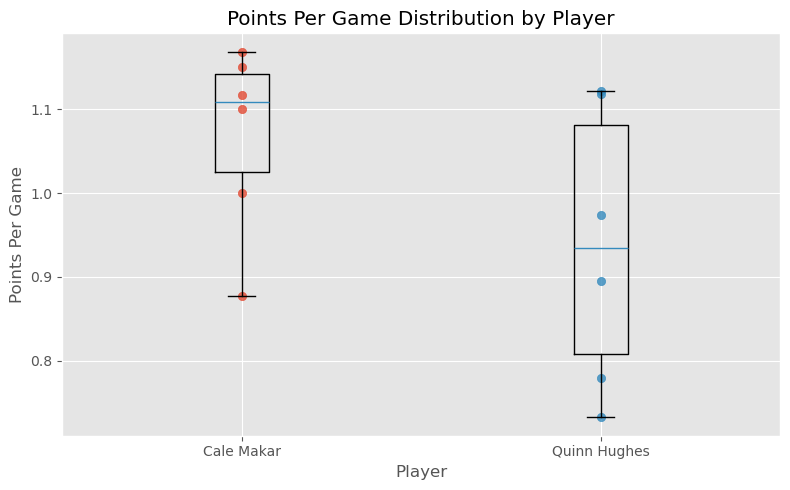

In [28]:
plt.figure(figsize=(8, 5))
player_order = ["Cale Makar", "Quinn Hughes"]
boxplot_data = [comparison_df.loc[comparison_df["name"] == player, "points_per_game"] for player in player_order]
plt.boxplot(boxplot_data, tick_labels=player_order)

for i, player in enumerate(player_order, start=1):
    y_values = comparison_df.loc[comparison_df["name"] == player, "points_per_game"]
    x_values = [i] * len(y_values)
    plt.scatter(x_values, y_values, alpha=0.8)

plt.title("Points Per Game Distribution by Player")
plt.xlabel("Player")
plt.ylabel("Points Per Game")
plt.tight_layout()
plt.show()


### Interpretation

Both players were strong over the full sample, but Makar looks slightly more reliable at a very high offensive level.

- Makar had the higher average points per game.
- Makar also had the lower standard deviation in points per game.
- Hughes was still productive, but his season-to-season scoring moved around a bit more.

This matters because the best trade target is usually not just the player with the highest peak, but also the player who is more likely to deliver top offense again.

---

## Step 4 – Final Recommendation

After comparing the two players across six shared seasons, I would recommend **Cale Makar**.

### Why I chose Makar

1. **He produced more total offense overall.**  
   Makar finished with **428 points**, compared with **406** for Hughes.

2. **He was the stronger scorer by a wide margin.**  
   Makar scored **116 goals**, while Hughes scored **59**.

3. **He generated more offensive pressure.**  
   Makar led in **shots on goal** and **expected goals**, which means his offense was supported by stronger chance creation.

4. **He was better on a per-game basis.**  
   Makar had the higher average in points per game, goals per game, shots per game, and xGoals per game.

5. **He looked slightly more consistent at an elite level.**  
   His points-per-game results were a little more stable across the six seasons.

Overall, Quinn Hughes would still be an excellent player to acquire, but the data in this notebook supports Cale Makar as the better choice if a general manager wants the defenseman with the stronger offensive impact over time.
